In [1]:
## init mongo db and fiftyone connection
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import fiftyone.brain as fob
from sklearn.preprocessing import normalize
import plotly.express as px
import skdim
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ot
from sklearn.manifold import TSNE
import cv2
from fiftyone import ViewField as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
import random
import os
import json
from PIL import Image

# ## renders plotly properly in a html instance. 
# import plotly.io as pio
# pio.renderers.default = "notebook"


In [3]:
## Load dataset and views from mongodb 
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("New_Caledonia")
wp_view = dataset.load_saved_view("West_Papua")

In [4]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC', 'train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 4, 7, 15, 41, 1, 463000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections':

## create roi

In [22]:

def add_roi_grid(dataset, tile_size=640, overlap=100):
    for sample in dataset:
        w = sample.metadata.width
        h = sample.metadata.height

        rois = []

        # Calculate stride
        stride = tile_size - overlap

        # Create overlapping grid coordinates
        for y in range(0, h, stride):
            for x in range(0, w, stride):
                # Ensure we don't go out of bounds
                x_end = min(x + tile_size, w)
                y_end = min(y + tile_size, h)

                # If the tile would be smaller than tile_size, adjust the start
                # to keep the tile size consistent
                x_start = x_end - tile_size if x_end - tile_size >= 0 else 0
                y_start = y_end - tile_size if y_end - tile_size >= 0 else 0

                # relative coordinates [top_left_x, top_left_y, width, height]
                rois.append(
                    fo.Detection(
                        label=f"tile_{y}_{x}",
                        bounding_box=[
                            x_start / w,
                            y_start / h,
                            tile_size / w,
                            tile_size / h
                        ]
                    )
                )

        sample["roi_grid"] = fo.Detections(detections=rois)
        sample.save()

# Apply the grid to your dataset
add_roi_grid(dataset, tile_size=640, overlap=100)

In [23]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC', 'train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 4, 7, 15, 23, 48, 43476),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections':

In [17]:
# On a cluster: auto=False prevents it trying to open a browser
# Use port forwarding: ssh -L 5151:localhost:5151 user@cluster
session = fo.launch_app(dataset,
                        port=5151,
                        auto=False)
print(session.url)  

Session launched. Run `session.show()` to open the App in a cell output.
http://localhost:5151/


## add and translate bbox inside roi_grid

In [30]:
# dataset.delete_sample_field("roi_grid.detections.slicing_check")
# dataset.delete_sample_field("roi_grid.detections.slicing_check_id")
# dataset.delete_sample_field("roi_grid.detections.slicing_eval")

dataset.delete_sample_field("roi_grid.detections.bbox_translated")
#dataset.delete_sample_field("roi_grid.detections.contains_dugong")

In [21]:
dataset.delete_sample_field("roi_grid")

In [29]:
next(iter(dataset.skip(10).take(1)))

<SampleView: {
    'id': '69add89acfd942e1c6b5dce6',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/WP/UM/UM_M5/images/MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_73.jpeg',
    'tags': ['UM_M5', 'UM', 'WP', 'fold_3', 'train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 1186355,
        'mime_type': 'image/jpeg',
        'width': 4096,
        'height': 2160,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 18, 699000),
    'last_modified_at': datetime.datetime(2026, 4, 7, 15, 40, 0, 340000),
    'region': 'WP',
    'subregion': 'UM',
    'mission_name': 'UM_M5',
    'sea_state': 1,
    'turbidity_global': 1,
    'turbidity_local': 'Unknown',
    'sun_glitter': '25-50',
    'cloud_reflection': '0-0',
    'habitat_type': 'sand',
    'background_complexity': 'medium',
    'coral': 'P',
    'sand': 'P',
    'dense_seagrass': 'P',
    'open_sea': 'A',
    'sparse_seagrass': 'A',
    'ground_truth': <Dete

In [ ]:

def clip_bbox(gt_bbox, tile_bbox):
    gx, gy, gw, gh = gt_bbox
    tx, ty, tw, th = tile_bbox

    # Calculate absolute coordinates
    gx1, gy1 = gx, gy
    gx2, gy2 = gx + gw, gy + gh
    tx1, ty1 = tx, ty
    tx2, ty2 = tx + tw, ty + th

    # Clip the bbox to the tile
    x1 = max(gx1, tx1)
    y1 = max(gy1, ty1)
    x2 = min(gx2, tx2)
    y2 = min(gy2, ty2)

    # If no overlap, return None
    if x1 >= x2 or y1 >= y2:
        return None

    # Return the clipped bbox in absolute coordinates
    return [x1, y1, x2 - x1, y2 - y1]

def normalize_bbox(clipped_bbox, tile_bbox):
    if clipped_bbox is None:
        return None
    x, y, w, h = clipped_bbox
    tx, ty, tw, th = tile_bbox

    # Normalize relative to the tile
    nx = (x - tx) / tw
    ny = (y - ty) / th
    nw = w / tw
    nh = h / th

    return [nx, ny, nw, nh]


def bbox_overlaps(gt_bbox, tile_bbox):
    gx, gy, gw, gh = gt_bbox
    tx, ty, tw, th = tile_bbox
    return not (
        gx + gw < tx or
        gy + gh < ty or
        gx > tx + tw or
        gy > ty + th
    )

for sample in dataset.iter_samples(autosave=True, progress=True):
    if sample.roi_grid is None:
        continue

    # For each tile, find overlapping dugongs
    for tile in sample.roi_grid.detections:
            tile_bbox = tile.bounding_box
            tile["dugongs"] = []
            for det in sample.ground_truth.detections:
                gt_bbox = det.bounding_box
                if bbox_overlaps(gt_bbox, tile_bbox):
                    clipped = clip_bbox(gt_bbox, tile_bbox)
                    if clipped:
                        normalized = normalize_bbox(clipped, tile_bbox)
                        tile["dugongs"].append({
                            "bbox_translated": normalized,
                            "dugong_id": det.id,
                            "og_bbox_clipped": clipped
                        })

    sample.save()

   0% |\--------------|   12/2755 [437.5ms elapsed, 1.7m remaining, 27.4 samples/s] 

 100% |███████████████| 2755/2755 [1.5m elapsed, 0s remaining, 19.9 samples/s]      


## convert to patches

In [4]:
## here I am passing a seed which can be leveraged inside a function afterwards 
## the idea is to hold a list of tiles_ID, which brings to more than one image ID.

## find the ids to be converted
negative_list_id = []
positive_list_id = []

random.seed(42)
for parent_id in dataset.values("id"):
    ## filter for the parent ID
    ## each parent is supposed to have a bunch of tiles inside it
    parent_sample_view = dataset.select(parent_id)

    # filter the detections within the "roi_grid" field - filtering for the given tiles
    # This keeps only the detection objects where 'contains_dugong' is False
    negative = parent_sample_view.filter_labels(
        "roi_grid", 
        F("contains_dugong") == False
    )

    positive = parent_sample_view.filter_labels(
        "roi_grid", 
        F("contains_dugong") == True
    )
    grid_roi_ids_neg = negative.values("roi_grid.detections.id", unwind=True) ## get all roi_grid ID for properly filtering
    grid_roi_ids_pos = positive.values("roi_grid.detections.id", unwind=True) 

    ## randomly select 2 images of the given
    negative_list_id.extend(random.choices(grid_roi_ids_neg, k=2))

    ## add the positive list of id
    positive_list_id.extend(grid_roi_ids_pos)

len(negative_list_id), len(positive_list_id)

(5510, 7253)

### continuar aqui

In [5]:
## with the given list we can filter the whole dataset based on the list

# create a Patches View
# a 'virtual' dataset where each sample is one 640x640 tile
tiles_view = dataset.to_patches("roi_grid",
                                 other_fields =['id','filepath',
                                                "audit",
                                                'region','subregion','mission_name','stratify_key'],
                                 keep_label_lists=True
                                  )


print(tiles_view.count_values('roi_grid.detections.contains_dugong'))


## here we are filtering the view based on the id of the tile
positive_tile_view = tiles_view.select(positive_list_id)
negative_tile_view = tiles_view.select(negative_list_id)
print(f"Total size to export POSITIVE SAMPLES: {len(positive_tile_view)}")
print(f"NEGATIVE SAMPLES: {len(negative_tile_view)}")



## combine both views
# Combine filtered views
export_view = positive_tile_view + negative_tile_view

print(f" Total length: {len(export_view)} tiles...")


{True: 7253, False: 71785}
Total size to export POSITIVE SAMPLES: 7253
NEGATIVE SAMPLES: 5379
 Total length: 12632 tiles...


In [23]:
for sample in export_view.take(1):
    print(sample)

<PatchView: {
    'id': '69d5218e6023668bb2bd2658',
    'media_type': 'image',
    'sample_id': '69add899cfd942e1c6b5d645',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_215/images/GH034215-61700518b18d1_1830.jpeg',
    'tags': ['Flight_215', 'NC', 'NC', 'train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 369999,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 17, 320000),
    'last_modified_at': datetime.datetime(2026, 4, 7, 15, 41, 1, 463000),
    'roi_grid': <Detections: {
        'detections': [
            <Detection: {
                'id': '69d5218e6023668bb2bd2658',
                'attributes': {},
                'tags': [],
                'label': 'tile_0_0',
                'bounding_box': [0.0, 0.0, 0.23668639053254437, 0.42105263157894735],
                'mask': None,
                'mask_path': None,
            

## export 

In [ ]:
seed_run = 42
root_dir = "/share/home/e2406743/dataset/exported_img"
seed_run_folder = f"seed_{str(seed_run)}"
output_dir = os.path.join(root_dir,seed_run_folder)
## create folder
os.makedirs(output_dir, exist_ok=True)


def bbox_to_yolo(bbox):
    x, y, w, h = bbox
    return [x + w / 2, y + h / 2, w, h]


for sample in export_view.take(2):
    stem  = Path(sample.filepath).stem
    tile_name = sample.roi_grid.detections[0].label
    print(f"{stem}")
    # Correctly identify if it's a positive or negative tile
    is_positive = sample.roi_grid.detections[0].contains_dugong
    label_str = "positive" if is_positive else "negative"
    label_str_alias = 'p' if is_positive else "n"
    
    final_name = f"{stem}__{tile_name}_{label_str_alias}"
    print(final_name)
    img_path  = os.path.join(output_dir, "images",   f"{final_name}.jpg")
    txt_path  = os.path.join(output_dir, "labels",   f"{final_name}.txt")
    json_path = os.path.join(output_dir, "metadata", f"{final_name}.json")

    ## create the folders
    for path in [img_path, txt_path, json_path]:
        os.makedirs(os.path.dirname(path), exist_ok=True)


    ## crop and tile image
    with Image.open(sample.filepath) as img:
        # Use metadata from the sample for precision
        W = sample.metadata.width
        H = sample.metadata.height
        
        # Access the tile's bounding box: [x, y, w, h] in normalized coordinates
        tx, ty, tw, th = sample.roi_grid.detections[0].bounding_box
        
        left = int(tx * W)
        top = int(ty * H)
        right = int((tx + tw) * W)
        bottom = int((ty + th) * H)
        
        # Pillow crop: (left, top, right, bottom)
        crop = img.crop((left, top, right, bottom))
        crop = crop.resize((640, 640), Image.LANCZOS)
        crop.save(img_path, quality=95)

    # --- YOLO label (Ground Truth) ---
    # get the yolo from the translated bbox
    dugong_id_list = []
    lines = []
    if is_positive:
        ## loop through all the dict inside dugongs
        for det in sample.roi_grid.detections[0].dugongs: ## it is a list with a dict inside 
            ## get the 
            # FiftyOne normalized [x, y, w, h] -> YOLO [x_center, y_center, w, h]
            bx, by, bw, bh = bbox_to_yolo(det['bbox_translated'])
            # Ensure coordinates are capped between 0 and 1
            x_c = max(0, min(1, bx + bw/2))
            y_c = max(0, min(1, by + bh/2))
            lines.append(f"0 {x_c} {y_c} {bw} {bh}")

            ## append dugong_id list to save in the metadata
            dugong_id_list.append(det['dugong_id'])

    with open(txt_path, "w") as f:
        f.write("\n".join(lines))

    # --- metadata ---
    meta = {
        "tile_id":        sample.id,
        "sample_id":      sample.sample_id,
        "source_image":   sample.filepath,
        "tile_name":      tile_name,
        "region":         sample.region,
        "subregion":      sample.subregion,
        "mission_name":   sample.mission_name,
        "stratify_key":   sample.stratify_key,
        "contains_dugong": label_str,
        "dugong_id":       dugong_id_list
    }
    with open(json_path, "w") as f:
        json.dump(meta, f, indent=2)

GH034196-60e7f35f21cd1_834
GH034196-60e7f35f21cd1_834_tile_540_1080__n
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_53
MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_53_tile_1080_1620__p


In [ ]:
sample

<PatchView: {
    'id': '69d5218c6023668bb2bd2183',
    'media_type': 'image',
    'sample_id': '69add899cfd942e1c6b5d600',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_220/images/GH034220-6196521ee3ef6_1720.jpeg',
    'tags': ['Flight_220', 'NC', 'NC', 'train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 360973,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 17, 274000),
    'last_modified_at': datetime.datetime(2026, 4, 7, 15, 41, 1, 463000),
    'roi_grid': <Detections: {
        'detections': [
            <Detection: {
                'id': '69d5218c6023668bb2bd2183',
                'attributes': {},
                'tags': [],
                'label': 'tile_0_2700',
                'bounding_box': [
                    0.7633136094674556,
                    0.0,
                    0.23668639053254437,
                    

### check the export

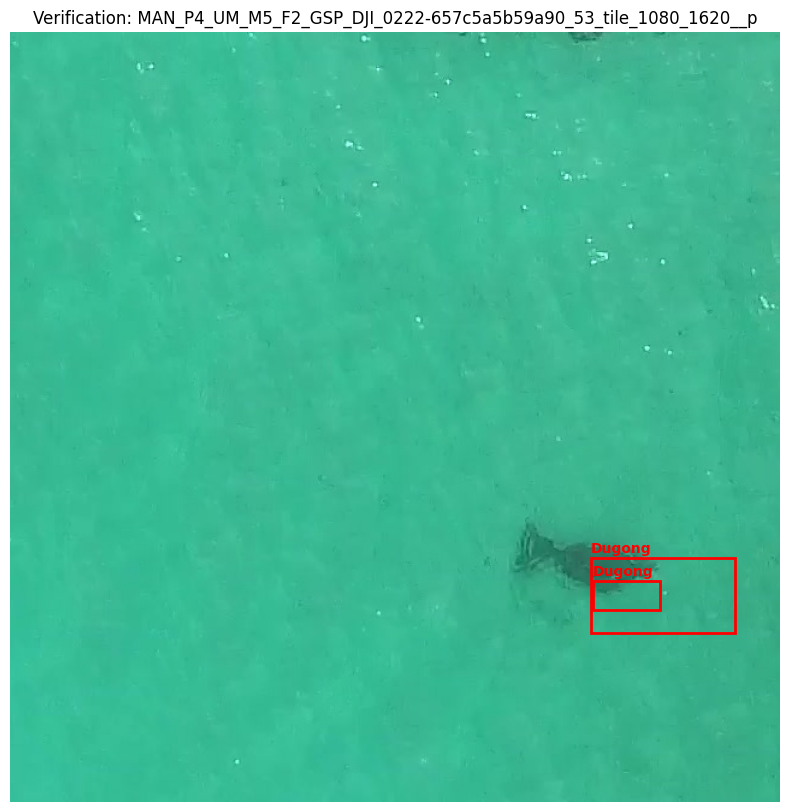

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

def verify_export(image_id, output_dir):
    """
    Loads an exported tile and its YOLO labels, then plots them.
    
    Args:
        image_id: The FiftyOne sample ID (or the ID used in the filename)
        output_dir: The base directory where you exported 'images' and 'labels'
        label_str: 'positive' or 'negative' (prefix used in filename)
    """
    stem = Path(image_id).stem
    img_path = os.path.join(output_dir, "images", f"{stem}.jpg")
    txt_path = os.path.join(output_dir, "labels", f"{stem}.txt")

    if not os.path.exists(img_path):
        print(f"Error: Image not found at {img_path}")
        return

    # 1. Load Image
    img = Image.open(img_path)
    img_w, img_h = img.size
    
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)
    
    # 2. Parse YOLO Labels
    if os.path.exists(txt_path):
        with open(txt_path, "r") as f:
            lines = f.readlines()
        
        for line in lines:
            # YOLO: class x_center y_center width height
            parts = line.strip().split()
            if not parts: continue
            
            _, xc, yc, w, h = map(float, parts)
            
            # Convert normalized center-based to pixel top-left based
            # x_min = (x_center - width / 2) * image_width
            x_min = (xc - w / 2) * img_w
            y_min = (yc - h / 2) * img_h
            pixel_w = w * img_w
            pixel_h = h * img_h
            
            # 3. Create Rectangle Patch
            rect = patches.Rectangle(
                (x_min, y_min), pixel_w, pixel_h, 
                linewidth=2, edgecolor='r', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x_min, y_min - 5, "Dugong", color='red', weight='bold')

    plt.title(f"Verification: {stem}")
    plt.axis('off')
    plt.show()

# Example usage:
verify_export("MAN_P4_UM_M5_F2_GSP_DJI_0222-657c5a5b59a90_53_tile_1080_1620__p.jpg",
               "/share/home/e2406743/dataset/exported_img/seed_42")

In [61]:
parent_ids_with_positives

[]

In [56]:
tiles_view.match(F("roi_grid.detections.contains_dugong") == True)

Dataset:     dugong
Media type:  image
Num patches: 0
Patch fields:
    id:               fiftyone.core.fields.ObjectIdField
    sample_id:        fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    roi_grid:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:           fiftyone.core.fields.StringField
    subregion:        fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    stratify_key:     fiftyone.core.fields.StringField
View stages:
    1. ToPatches(field='roi_grid', config={'keep_label_lists': True, 'other_fields': ['id', 'filepath', 'region', ...]})
    2. 

In [ ]:
## export all true images and 
import os
import json
from PIL import Image
import fiftyone as fo
from tqdm import tqdm

def export_metadata_manifest(dataset, run_number, output_base_dir, bg_ratio=2):
    """
    Physically crops tiles and creates a JSON manifest with full metadata.
    """
    run_dir = os.path.join(output_base_dir, f"run_{run_number}")
    images_dir = os.path.join(run_dir, "patches")
    os.makedirs(images_dir, exist_ok=True)

    manifest = []
    
    # We process Train, Val, and Test separately
    for split in ["train", "val", "test"]:
        split_tag = f"{split}_run{run_number}"
        view = dataset.match_tags(split_tag)
        
        print(f"Processing {split} for Run {run_number}...")

        for sample in view.progress_view():
            # Load the original high-res image once per sample
            with Image.open(sample.filepath) as img:
                w, h = img.size
                
                for i, tile in enumerate(sample.roi_grid.detections):
                    # 1. Determine if we should export this tile
                    is_positive = tile.get("contains_dugong", False)
                    
                    # Logic: Always keep positives. For negatives in training, 
                    # we can sub-sample later in the dataloader using the manifest.
                    # For now, let's export all positives and a balanced set of negatives.
                    if not is_positive and split == "train":
                        # Simple skip logic to keep the disk space manageable
                        if i % 10 != 0: continue 

                    # 2. Calculate Pixel Coordinates for the Crop
                    tx, ty, tw, th = tile.bounding_box
                    left = tx * w
                    top = ty * h
                    right = (tx + tw) * w
                    bottom = (ty + th) * h
                    
                    # 3. Perform the physical crop
                    patch_filename = f"{sample.id}_tile_{i}.jpg"
                    patch_path = os.path.join(images_dir, patch_filename)
                    
                    if not os.path.exists(patch_path):
                        tile_img = img.crop((left, top, right, bottom))
                        tile_img.convert("RGB").save(patch_path, quality=95)

                    # 4. Build the Metadata Entry
                    entry = {
                        "patch_path": os.path.abspath(patch_path),
                        "split": split,
                        "parent_id": str(sample.id),
                        "region": sample.region,
                        "mission": sample.mission_name,
                        "background_complexity": sample.background_complexity,
                        "contains_dugong": is_positive,
                        "labels": tile.get("dugongs", []) # This contains your bbox_translated!
                    }
                    manifest.append(entry)

    # Save the manifest as the 'Source of Truth' for your Dataloader
    manifest_path = os.path.join(run_dir, f"manifest_run_{run_number}.json")
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=4)
        
    print(f"Export complete. Manifest saved at: {manifest_path}")

# Execute
export_metadata_manifest(dataset, run_number=1, output_base_dir="./Dugong_Thesis_Exports")

In [40]:
tiles_view.count_values('roi_grid.detections.contains_dugong')

{True: 7253, False: 71785}

In [ ]:
tiles_view.match(
    F("roi_grid.detections.contains_dugong").)


SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (3892188808.py, line 2)

In [9]:
len(tiles_with_dugongs)

79038

In [10]:
len(background_tiles)

0

In [11]:
tiles_view

Dataset:     dugong
Media type:  image
Num patches: 79038
Patch fields:
    id:               fiftyone.core.fields.ObjectIdField
    sample_id:        fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    roi_grid:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detection)
    region:           fiftyone.core.fields.StringField
    subregion:        fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    stratify_key:     fiftyone.core.fields.StringField
View stages:
    1. ToPatches(field='roi